# Selekcija instanci - Praktican deo

## Ucitavanje i osnovna analiza skupa podataka
Prvo je potrebno ucitati podatke iz dataset-a Wine Quality i izvrsiti osnovnu analiza strukture podataka, tipovi atributa i ukupnog broja instanci.

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

import time

from imblearn.under_sampling import (
    EditedNearestNeighbours,
    RepeatedEditedNearestNeighbours,
    AllKNN,
    CondensedNearestNeighbour,
    TomekLinks
)

import warnings
warnings.filterwarnings('ignore')

In [145]:
df = pd.read_csv('data/winequality-red.csv')

print("Dimenzije skupa podataka: ", df.shape)
df.head()

Dimenzije skupa podataka:  (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Dimenzije skupa podataka
Proveravamo tipove podataka i nedostajuce vrednosti. Tipovi su bitni jer k-NN zahteva numericke atribute, a nedostajuce vrednosti bi morale da se imputuju pre primene bilo kog algoritma zasnovanog na rastojanju.

In [146]:
print(f"Tipovi podataka:")
print(df.dtypes)
print(f"\nNedostajuce vrednosti po atributu:")
print(df.isnull().sum())
print(f"\nUkupno nedostajućih vrednosti: {df.isnull().sum().sum()}")

Tipovi podataka:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Nedostajuce vrednosti po atributu:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Ukupno nedostajućih vrednosti: 0


## Osnovna statistika numerickih atributa
Prikaz osnovnih statistickih mera (srednja vrednost, standardna devijacija, minimum, maksimum i kvartili) daje uvid u raspodelu atributa i njihove opsege vrednosti, sto je bitno jer k-NN koristi Euklidsko rastojanje i atributi sa vecim opsegom bi dominirali nad ostalima.

In [147]:
df.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


## Distribucija ciljne promenljive
Analiza distribucije klasa je kljucna za selekciju instanci. Nebalansiranost klasa direktno utice na k-NN jer ako vecina instanci pripada jednoj klasi, vecina najblizih suseda ce uvek biti iz te klase, sto dovodi do pristrasne klasifikacije.

Distribucija klasa (quality):
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Procentualna zastupljenost:
quality
3     0.6
4     3.3
5    42.6
6    39.9
7    12.4
8     1.1
Name: proportion, dtype: float64


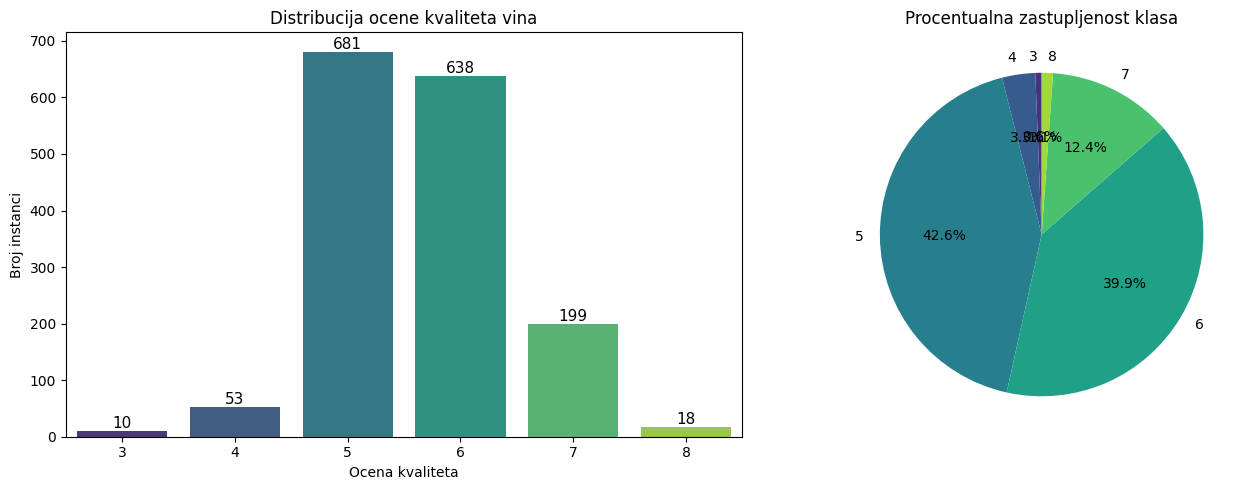

In [148]:
print("Distribucija klasa (quality):")
print(df['quality'].value_counts().sort_index())
print(f"\nProcentualna zastupljenost:")
print((df['quality'].value_counts(normalize=True).sort_index() * 100).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='quality', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Distribucija ocene kvaliteta vina')
axes[0].set_xlabel('Ocena kvaliteta')
axes[0].set_ylabel('Broj instanci')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
axes[1].pie(df['quality'].value_counts().sort_index(),
            labels=df['quality'].value_counts().sort_index().index,
            autopct='%1.1f%%',
            colors=sns.color_palette('viridis', 6),
            startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa')

plt.tight_layout()
plt.show()

Distribucija pokazuje izrazitu nebalansiranost klasa. Klase 5 i 6 zajedno cine oko 82.5% svih instanci (681 + 638 = 1319), dok klase 3 i 8 imaju samo 10 i 18 primeraka. Ovo je klasican primer nebalansiranosti koji direktno utice na k-NN klasifikator. Vecina najblizih suseda nove instance ce gotovo uvek pripadati klasama 5 ili 6, sto znaci da ce retke klase biti sistematski pogresno klasifikovane.

Sa 6 klasa od kojih neke imaju manje od 20 instanci, klasifikacija bi bila nepouzdana. Zbog toga cemo grupisati ocene u tri kategorije: los kvalitet (3-5), srednji kvalitet (6) i dobar kvalitet (7-8), cime dobijamo manji broj klasa sa dovoljnim brojem instanci u svakoj za smislenu primenu selekcije instanci.

## Grupisanje klasa
Posto originalni dataset ima 6 klasa od kojih neke imaju manje od 20 instanci, grupisemo ocene u tri kategorije kako bismo dobili dovoljno primeraka u svakoj klasi za pouzdanu klasifikaciju i smislenu primenu metoda selekcije instanci.

Distribucija grupisanih klasa:
quality_class
0    744
1    638
2    217
Name: count, dtype: int64

Procentualna zastupljenost:
quality_class
0    46.5
1    39.9
2    13.6
Name: proportion, dtype: float64


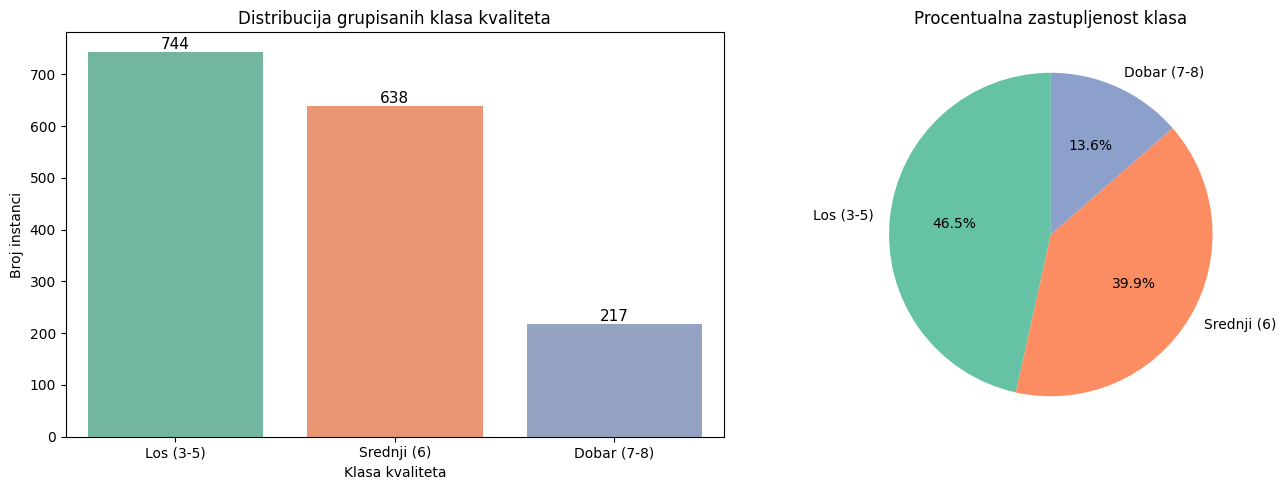

In [149]:
def map_quality(q):
    if q <= 5:
        return 0  # Los kvalitet
    elif q == 6:
        return 1  # Srednji kvalitet
    else:
        return 2  # Dobar kvalitet

df['quality_class'] = df['quality'].apply(map_quality)

print("Distribucija grupisanih klasa:")
print(df['quality_class'].value_counts().sort_index())
print(f"\nProcentualna zastupljenost:")
print((df['quality_class'].value_counts(normalize=True).sort_index() * 100).round(1))

labels = ['Los (3-5)', 'Srednji (6)', 'Dobar (7-8)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = sns.countplot(x='quality_class', data=df, palette='Set2', ax=axes[0])
ax.set_xticklabels(labels)
axes[0].set_title('Distribucija grupisanih klasa kvaliteta')
axes[0].set_xlabel('Klasa kvaliteta')
axes[0].set_ylabel('Broj instanci')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

axes[1].pie(df['quality_class'].value_counts().sort_index(), 
            labels=labels,
            autopct='%1.1f%%', 
            colors=sns.color_palette('Set2', 3),
            startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa')

plt.tight_layout()
plt.show()

Nakon grupisanja imamo tri klase: los kvalitet sa 744 instance (46.5%), srednji sa 638 (39.9%) i dobar sa 217 (13.6%). Klase su i dalje nebalansirane. Klasa 2 (dobar kvalitet) ima skoro 3.5 puta manje instanci od klase 0, sto znaci da ce k-NN i dalje teziti da favorizuje klase 0 i 1. Medjutim, sada svaka klasa ima dovoljno instanci za pouzdanu klasifikaciju i evaluaciju metoda selekcije instanci.

## Distribucije atributa
Vizualizacija distribucija svih numerickih atributa pomaze da se identifikuju outlieri i asimetricne distribucije. Ovo je relevantno za selekciju instanci jer outlieri i instance sa ekstremnim vrednostima su upravo one koje edition metode poput ENN ciljaju za uklanjanje.

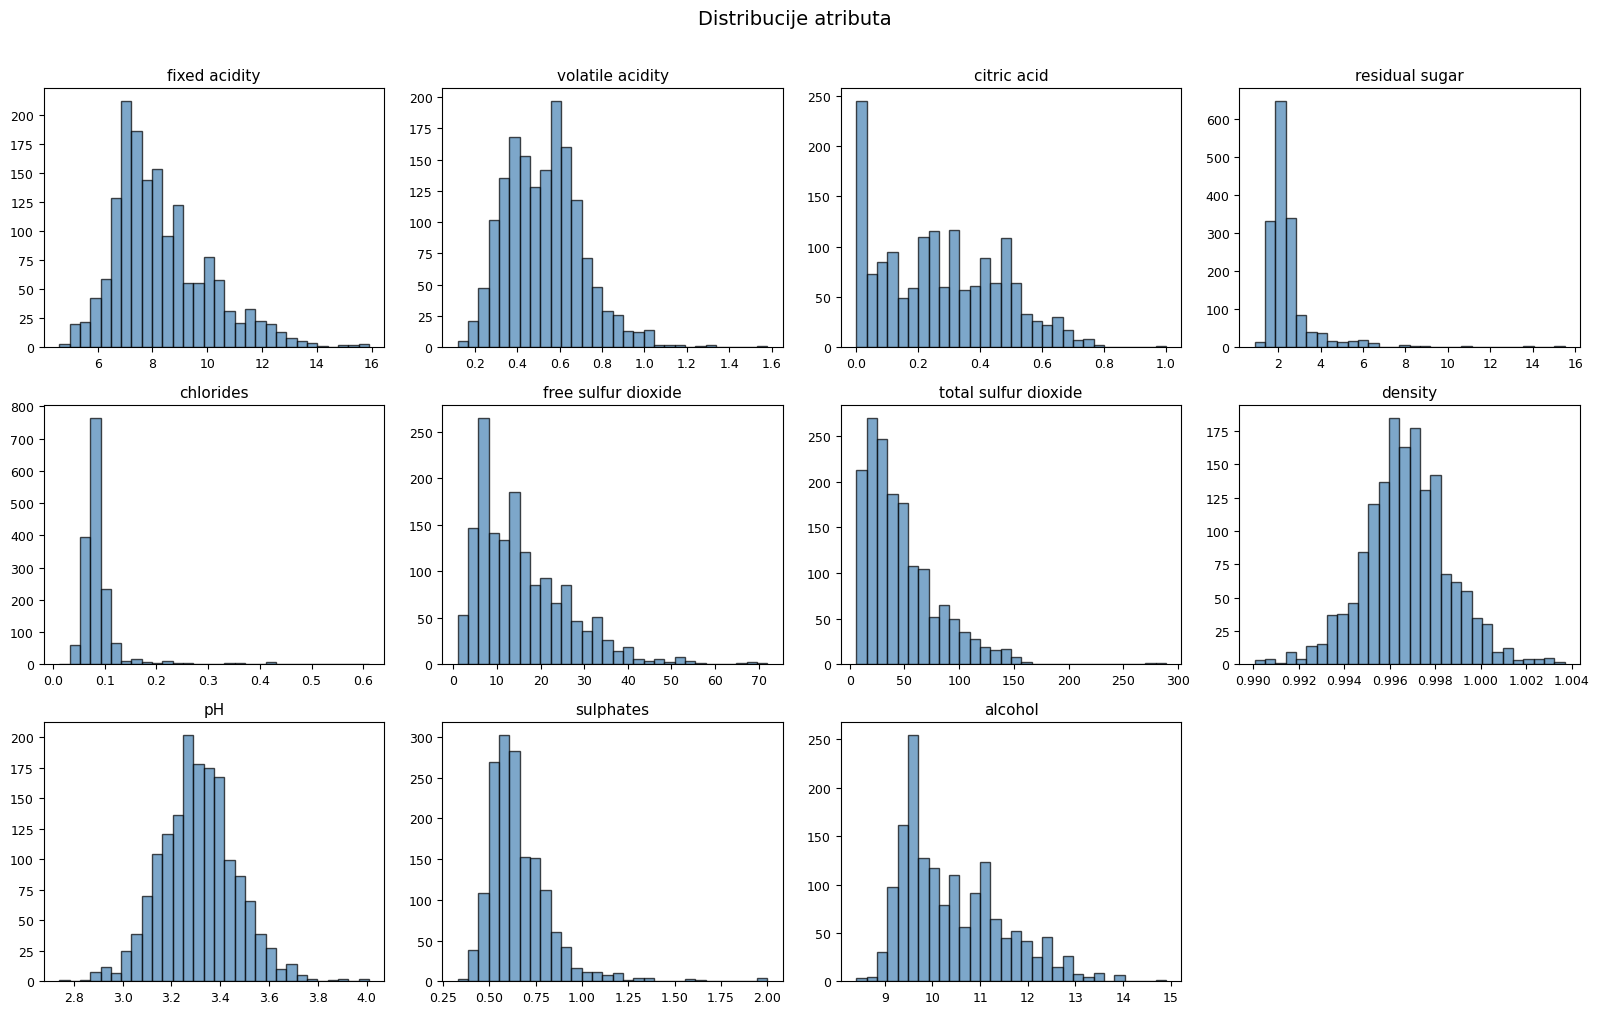

In [150]:
features = df.columns[:-2]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].tick_params(labelsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribucije atributa', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Vecina atributa ima asimetricnu distribuciju sa desnim repom, posebno `residual sugar`, `chlorides`, `sulphates` i `total sulfur dioxide`. Dugi repovi ukazuju na prisustvo outliera, instanci sa ekstremnim vrednostima koje se nalaze daleko od centra distribucije. Atributi `pH` i `density` imaju priblizno normalnu distribuciju. Ovi outlieri su potencijalni kandidati za uklanjanje edition metodama jer se cesto nalaze u blizini instanci druge klase i mogu negativno uticati na k-NN klasifikaciju.

## Korelaciona matrica
Analiza korelacija izmedju atributa pomaze da se razume struktura podataka i identifikuju potencijalno redundantni atributi koji ne doprinose dodatnim informacijama za klasifikaciju.

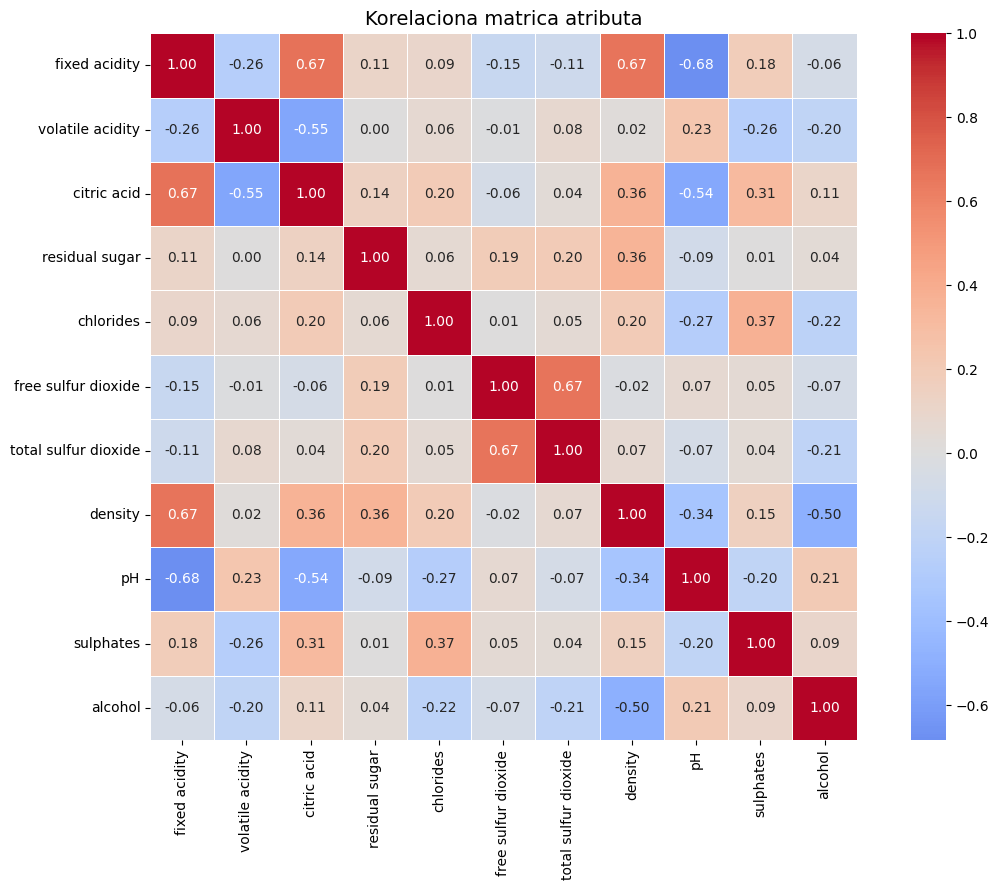

In [151]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Korelaciona matrica atributa', fontsize=14)
plt.tight_layout()
plt.show()

## Box plotovi po klasama
Box plotovi pokazuju kako se distribucije atributa razlikuju izmedju klasa kvaliteta. Atributi sa jasnom razlikom izmedju klasa su najinformativniji za klasifikaciju, dok oni sa velikim preklapanjem stvaraju granicne oblasti gde k-NN pravi greske i gde selekcija instanci moze da pomogne.

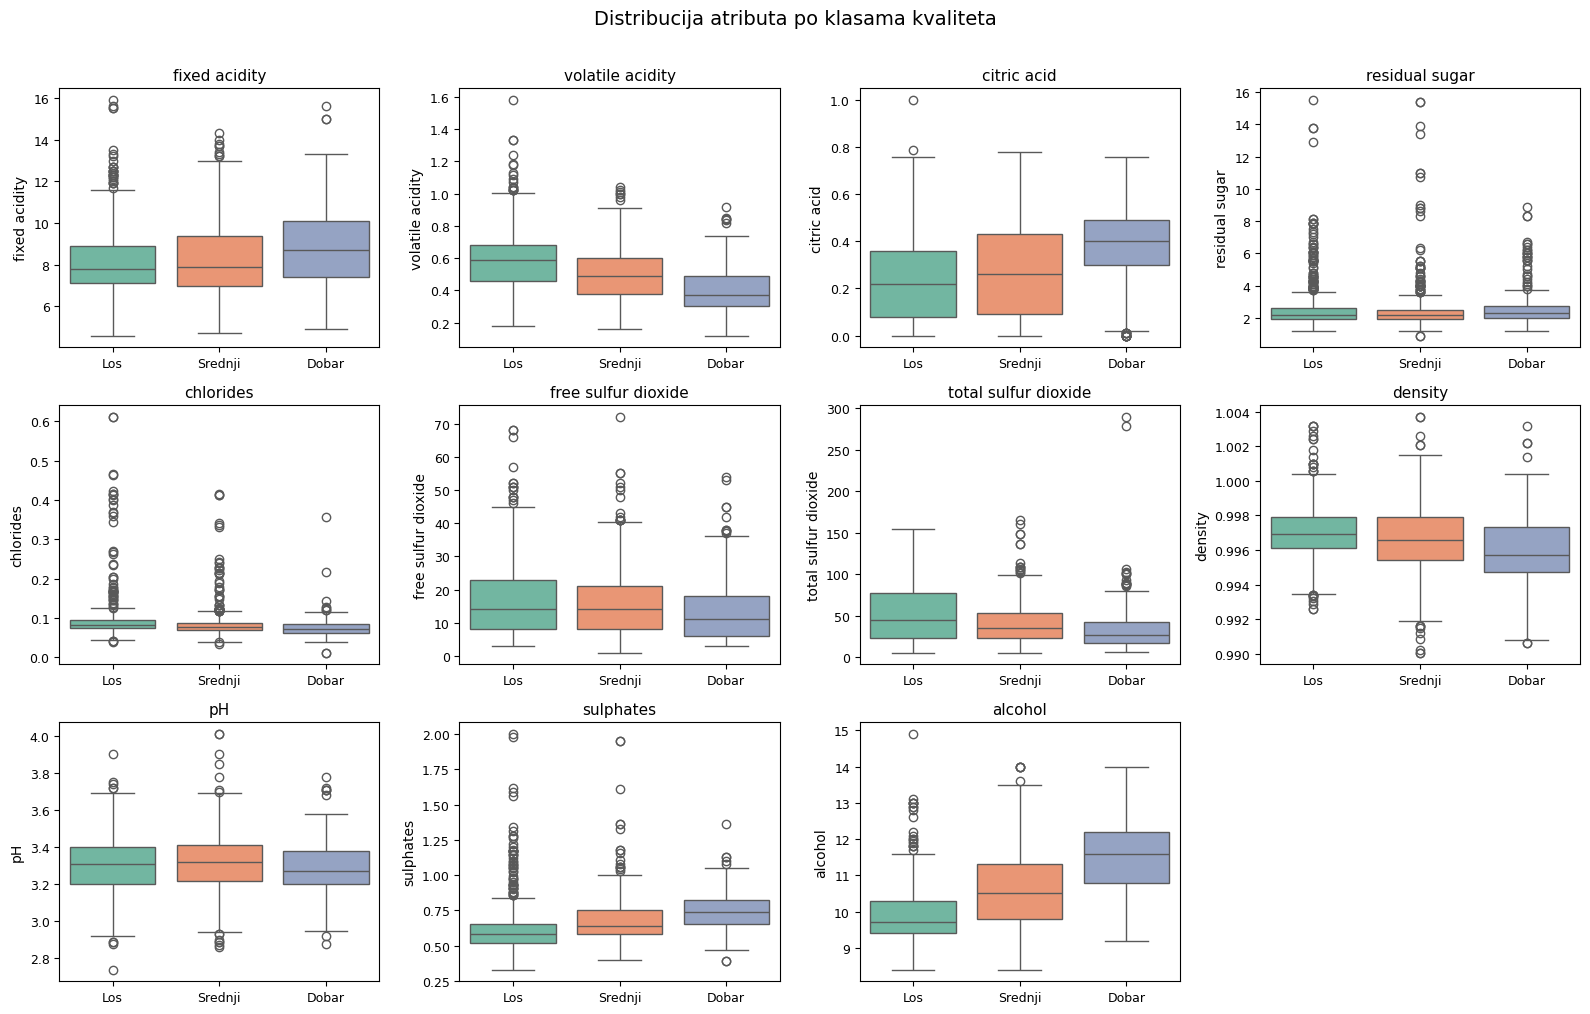

In [152]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
labels = ['Los', 'Srednji', 'Dobar']

for i, col in enumerate(features):
    sns.boxplot(x='quality_class', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(labels)
    axes[i].tick_params(labelsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribucija atributa po klasama kvaliteta', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Iz box plotova se vidi da `alcohol` i `volatile acidity` imaju najjasniju razliku izmedju klasa, dok atributi poput `residual sugar` i `pH` imaju veliko preklapanje. Takodje, vecina atributa sadrzi outliere koji su potencijalni kandidati za uklanjanje edition metodama.

## Priprema podataka za klasifikaciju
Odvajamo atribute od ciljne promenljive, delimo podatke na trening (70%) i test (30%) skup, i standardizujemo atribute. Standardizacija je neophodna jer k-NN koristi Euklidsko rastojanje. Bez nje bi atributi sa vecim opsegom dominirali. Bitno je da se `fit_transform` radi samo na trening skupu, a na test skupu samo `transform`, kako informacije iz test skupa ne bi uticale na treniranje (data leakage).

In [153]:
X = df[features]
y = df['quality_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Trening skup: {X_train_scaled.shape[0]} instanci")
print(f"Test skup: {X_test_scaled.shape[0]} instanci")
print(f"\nDistribucija klasa u trening skupu:")
print(y_train.value_counts().sort_index())
print(f"\nDistribucija klasa u test skupu:")
print(y_test.value_counts().sort_index())

Trening skup: 1119 instanci
Test skup: 480 instanci

Distribucija klasa u trening skupu:
quality_class
0    521
1    446
2    152
Name: count, dtype: int64

Distribucija klasa u test skupu:
quality_class
0    223
1    192
2     65
Name: count, dtype: int64


## Baseline k-NN klasifikacija
Pre primene bilo koje metode selekcije instanci, potrebno je uspostaviti baseline rezultate. Performanse k-NN klasifikatora treniranog na kompletnom trening skupu bez ikakvih modifikacija. Ovi rezultati sluze kao referentna tacka sa kojom cemo porediti rezultate nakon primene selekcije instanci. Merimo i vreme treniranja i predikcije jer je jedan od glavnih ciljeva selekcije instanci upravo ubrzanje.

In [154]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

start_time = time.time()
knn.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

start_time = time.time()
y_pred = knn.predict(X_test_scaled)
predict_time = time.time() - start_time

print(f"Baseline k-NN (k={k})")
print(f"Broj instanci u trening skupu: {X_train_scaled.shape[0]}")
print(f"Vreme treniranja: {train_time:.4f}s")
print(f"Vreme predikcije: {predict_time:.4f}s")
print(f"\nTacnost: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred, target_names=['Los', 'Srednji', 'Dobar']))

Baseline k-NN (k=5)
Broj instanci u trening skupu: 1119
Vreme treniranja: 0.0015s
Vreme predikcije: 0.0446s

Tacnost: 0.6438

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.73      0.70      0.72       223
     Srednji       0.58      0.61      0.60       192
       Dobar       0.56      0.52      0.54        65

    accuracy                           0.64       480
   macro avg       0.62      0.61      0.62       480
weighted avg       0.65      0.64      0.64       480



## Confusion matrica (Baseline)
Confusion matrica prikazuje koliko je instanci iz svake klase pravilno i pogresno klasifikovano, sto omogucava da se identifikuju problematicni parovi klasa gde dolazi do najveceg mesanja.

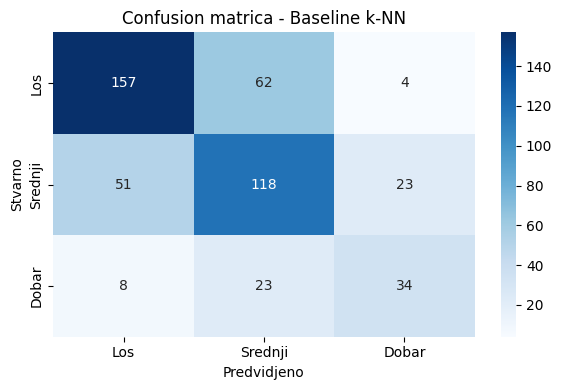

In [155]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Los', 'Srednji', 'Dobar'],
            yticklabels=['Los', 'Srednji', 'Dobar'])
plt.title('Confusion matrica - Baseline k-NN')
plt.xlabel('Predvidjeno')
plt.ylabel('Stvarno')
plt.tight_layout()
plt.show()

Najvece mesanje je izmedju klasa Los i Srednji, 62 instance klase Los su pogresno klasifikovane kao Srednji, i 51 instanca klase Srednji kao Los. Ovo ukazuje na veliko preklapanje izmedju ove dve klase u feature space-u, sto znaci da se u tim oblastima nalaze sumne i granicne instance koje zbunjuju k-NN klasifikator. Selekcija instanci moze da pomogne ovde. Edition metode uklanjanjem sumnih instanci sa granice, a kondenzacija zadrzavanjem samo kriticnih boundary instanci.

## Primena metoda selekcije instanci
U ovom delu primenjujemo metode selekcije instanci koje su obradjene u teorijskom delu rada. Koristimo biblioteku imbalanced-learn koja implementira ove metode. Svaku metodu primenjujemo na trening skup, zatim treniramo k-NN na redukovanom skupu i poredimo rezultate sa baseline-om. Za svaku metodu pratimo tacnost, F1-score, stopu redukcije i vreme predikcije.

In [156]:
results = []

results.append({
    'Method': 'Baseline (without selection)',
    'Num of instances': X_train_scaled.shape[0],
    'Reduction (%)': 0.0,
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time
})

print(f"Vreme predvidjanja: {predict_time}")
print(f"Baseline sacuvan: {X_train_scaled.shape[0]} instanci, tacnost: {accuracy_score(y_test, y_pred):.4f}")

Vreme predvidjanja: 0.044609785079956055
Baseline sacuvan: 1119 instanci, tacnost: 0.6438


## Edited Nearest Neighbours (ENN)
ENN je edition metoda koja uklanja instance ciji se najblizi susedi vecinski nalaze u drugoj klasi. Takve instance su verovatno sumne ili pogresno oznacene. ENN ne cilja drasticnu redukciju vec poboljsanje kvaliteta podataka — ocekujemo umerenu redukciju (10-30%) sa potencijalnim poboljsanjem tacnosti.

In [157]:
enn = EditedNearestNeighbours(n_neighbors=3)
X_enn, y_enn = enn.fit_resample(X_train_scaled, y_train)

knn_enn = KNeighborsClassifier(n_neighbors=k)
knn_enn.fit(X_enn, y_enn)

start_time = time.time()
y_pred_enn = knn_enn.predict(X_test_scaled)
predict_time_enn = time.time() - start_time

reduction = (1 - len(X_enn) / len(X_train_scaled)) * 100
acc_enn = accuracy_score(y_test, y_pred_enn)

results.append({
    'Method': 'ENN',
    'Num of instances': len(X_enn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_enn,
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time_enn
})

print(f"ENN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_enn)} (redukcija: {reduction:.1f}%)")
print(f"Tacnost: {acc_enn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_enn, target_names=['Los', 'Srednji', 'Dobar']))

ENN rezultati:
Broj instanci: 1119 -> 447 (redukcija: 60.1%)
Tacnost: 0.5583 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.72      0.68      0.70       223
     Srednji       0.55      0.34      0.42       192
       Dobar       0.35      0.80      0.48        65

    accuracy                           0.56       480
   macro avg       0.54      0.61      0.53       480
weighted avg       0.60      0.56      0.56       480



ENN je uklonio 60.1% instanci, sto je znatno vise od tipicnih 10-30%. Ovo ukazuje na veliko preklapanje izmedju klasa u feature space-u. Tacnost je pala sa 0.64 na 0.56 jer je ENN bio preagresivan, uklonio je i validne granicne instance, posebno iz klase Srednji ciji je recall pao sa 0.61 na 0.34.

## Repeated Edited Nearest Neighbours (RENN)
RENN iterativno primenjuje ENN dok god se uklanjaju instance. Ovo omogucava uklanjanje klastera sumnih instanci koje obican ENN ne detektuje u jednom prolazu jer se medjusobno podrzavaju. Ocekujemo vecu redukciju od ENN-a ali sa rizikom dodatnog pada tacnosti.

In [158]:
renn = RepeatedEditedNearestNeighbours(n_neighbors=3)
X_renn, y_renn = renn.fit_resample(X_train_scaled, y_train)

knn_renn = KNeighborsClassifier(n_neighbors=k)
knn_renn.fit(X_renn, y_renn)

start_time = time.time()
y_pred_renn = knn_renn.predict(X_test_scaled)
predict_time_renn = time.time() - start_time

reduction = (1 - len(X_renn) / len(X_train_scaled)) * 100
acc_renn = accuracy_score(y_test, y_pred_renn)

results.append({
    'Method': 'RENN',
    'Num of instances': len(X_renn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_renn,
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time_renn
})

print(f"RENN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_renn)} (redukcija: {reduction:.1f}%)")
print(f"Tacnost: {acc_renn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_renn, target_names=['Los', 'Srednji', 'Dobar']))

RENN rezultati:
Broj instanci: 1119 -> 447 (redukcija: 60.1%)
Tacnost: 0.5583 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.72      0.68      0.70       223
     Srednji       0.55      0.34      0.42       192
       Dobar       0.35      0.80      0.48        65

    accuracy                           0.56       480
   macro avg       0.54      0.61      0.53       480
weighted avg       0.60      0.56      0.56       480



RENN je dao identican rezultat kao ENN: istih 447 instanci, ista tacnost 0.5583. Ovo ukazuje na to da je ENN u prvom prolazu vec uklonio sve instance koje RENN bi mogao da detektuje. Nakon prvog prolaza nije ostao nijedan klaster sumnih instanci koji bi se otkrio u sledecim iteracijama. RENN je konvergirao u jednoj iteraciji.

## AllKNN
AllKNN je konzervativnija varijanta ENN-a koja primenjuje ENN sa vise razlicitih vrednosti k (od 1 do n_neighbors). Instanca se uklanja samo ako je pogresno klasifikovana za sve testirane vrednosti k, sto znaci da mora postojati jak signal da je instanca problematicna. Ocekujemo manju redukciju ali potencijalno bolje ocuvanje tacnosti jer se ne uklanjaju validne granicne instance.

In [159]:
allknn = AllKNN(n_neighbors=3)
X_allknn, y_allknn = allknn.fit_resample(X_train_scaled, y_train)

knn_allknn = KNeighborsClassifier(n_neighbors=k)
knn_allknn.fit(X_allknn, y_allknn)

start_time = time.time()
y_pred_allknn = knn_allknn.predict(X_test_scaled)
predict_time_allknn = time.time() - start_time

reduction = (1 - len(X_allknn) / len(X_train_scaled)) * 100
acc_allknn = accuracy_score(y_test, y_pred_allknn)

results.append({
    'Method': 'AllKNN',
    'Num of instances': len(X_allknn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_allknn,
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time_allknn
})

print(f"AllKNN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_allknn)} (redukcija: {reduction:.1f}%)")
print(f"Tacnost: {acc_allknn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_allknn, target_names=['Los', 'Srednji', 'Dobar']))

AllKNN rezultati:
Broj instanci: 1119 -> 474 (redukcija: 57.6%)
Tacnost: 0.5750 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.73      0.68      0.70       223
     Srednji       0.57      0.36      0.44       192
       Dobar       0.37      0.86      0.52        65

    accuracy                           0.57       480
   macro avg       0.56      0.63      0.55       480
weighted avg       0.62      0.57      0.57       480



AllKNN je ocuvao 27 instanci vise od ENN-a zahvaljujuci konzervativnijem pristupu, uz blago bolju tacnost (0.575 vs 0.558). Ipak, tacnost je i dalje ispod baseline-a, sto potvrdjuje da je preklapanje izmedju klasa u ovom datasetu previse izrazeno da bi edition metode same mogle da ga rese.

## Condensed Nearest Neighbour (CNN)
CNN je metoda kondenzacije koja zadrzava samo instance neophodne za pravilnu klasifikaciju. Uglavnom granicne instance izmedju klasa. Za razliku od edition metoda koje ciljaju kvalitet podataka, CNN cilja maksimalnu redukciju velicine. Ocekujemo drasticnu redukciju (70-95%) ali sa mogucim padom tacnosti jer CNN ne uklanja sum vec moze i da ga zadrzi.

In [160]:
cnn = CondensedNearestNeighbour(random_state=42)
X_cnn, y_cnn = cnn.fit_resample(X_train_scaled, y_train)

knn_cnn = KNeighborsClassifier(n_neighbors=k)
knn_cnn.fit(X_cnn, y_cnn)

start_time = time.time()
y_pred_cnn = knn_cnn.predict(X_test_scaled)
predict_time_cnn = time.time() - start_time

reduction = (1 - len(X_cnn) / len(X_train_scaled)) * 100
acc_cnn = accuracy_score(y_test, y_pred_cnn)

results.append({
    'Method': 'CNN',
    'Num of instances': len(X_cnn),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_cnn,
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time_cnn
})

print(f"CNN rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_cnn)} (redukcija: {reduction:.1f}%)")
print(f"Tacnost: {acc_cnn:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_cnn, target_names=['Los', 'Srednji', 'Dobar']))

CNN rezultati:
Broj instanci: 1119 -> 432 (redukcija: 61.4%)
Tacnost: 0.5500 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.67      0.64      0.66       223
     Srednji       0.48      0.43      0.45       192
       Dobar       0.40      0.58      0.48        65

    accuracy                           0.55       480
   macro avg       0.52      0.55      0.53       480
weighted avg       0.56      0.55      0.55       480



CNN je postigao najvecu redukciju (61.4%) ali i najnizu tacnost (0.55). CNN zadrzava granicne instance ali ne razlikuje validne od sumnih, sto degradira klasifikaciju. Ovo motivise hibridne metode poput DROP3 koje prvo ciste sum pa onda kondenzuju. DROP3 nije demonstriran u prakticnom delu jer ne postoji gotova Python biblioteka koja ga implementira.

## Tomek Links
Tomek Links identifikuje parove najblizih suseda koji pripadaju razlicitim klasama i uklanja instancu iz vecinske klase. Ovo metoda cilja samo najociglednije granicne konflikte i postize najmanju redukciju, ali sa minimalnim rizikom od gubitka korisnih instanci.

In [161]:
tomek = TomekLinks()
X_tomek, y_tomek = tomek.fit_resample(X_train_scaled, y_train)

knn_tomek = KNeighborsClassifier(n_neighbors=k)
knn_tomek.fit(X_tomek, y_tomek)

start_time = time.time()
y_pred_tomek = knn_tomek.predict(X_test_scaled)
predict_time_tomek = time.time() - start_time

reduction = (1 - len(X_tomek) / len(X_train_scaled)) * 100
acc_tomek = accuracy_score(y_test, y_pred_tomek)

results.append({
    'Method': 'Tomek Links',
    'Num of instances': len(X_tomek),
    'Reduction (%)': round(reduction, 1),
    'Accuracy': acc_tomek,
    'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
    'Predict time (s)': predict_time_tomek
})

print(f"Tomek Links rezultati:")
print(f"Broj instanci: {len(X_train_scaled)} -> {len(X_tomek)} (redukcija: {reduction:.1f}%)")
print(f"Tacnost: {acc_tomek:.4f} (baseline: {accuracy_score(y_test, y_pred):.4f})")
print(f"\nKlasifikacioni izvestaj:")
print(classification_report(y_test, y_pred_tomek, target_names=['Los', 'Srednji', 'Dobar']))

Tomek Links rezultati:
Broj instanci: 1119 -> 986 (redukcija: 11.9%)
Tacnost: 0.6375 (baseline: 0.6438)

Klasifikacioni izvestaj:
              precision    recall  f1-score   support

         Los       0.73      0.72      0.72       223
     Srednji       0.58      0.56      0.57       192
       Dobar       0.51      0.58      0.55        65

    accuracy                           0.64       480
   macro avg       0.61      0.62      0.61       480
weighted avg       0.64      0.64      0.64       480



Tomek Links je uklonio samo 11.9% instanci ali sacuvao tacnost skoro identicnu baseline-u (0.6375 vs 0.6438). Ovo je najmanji pad tacnosti od svih metoda, sto potvrdjuje da konzervativniji pristup bolje cuva kvalitet klasifikacije na ovom datasetu.

## Uporedna analiza rezultata
Poredjenje svih primenjenih metoda selekcije instanci sa baseline k-NN klasifikatorom. Tabela prikazuje broj preostalih instanci, stopu redukcije, tacnost i vreme predikcije za svaku metodu.

                      Method  Num of instances  Reduction (%)  Accuracy  F1 (weighted)  Predict time (s)
Baseline (without selection)              1119            0.0    0.6438       0.644368            0.0446
                         ENN               447           60.1    0.5583       0.644368            0.0025
                        RENN               447           60.1    0.5583       0.644368            0.0026
                      AllKNN               474           57.6    0.5750       0.644368            0.0025
                         CNN               432           61.4    0.5500       0.644368            0.0022
                 Tomek Links               986           11.9    0.6375       0.644368            0.0048


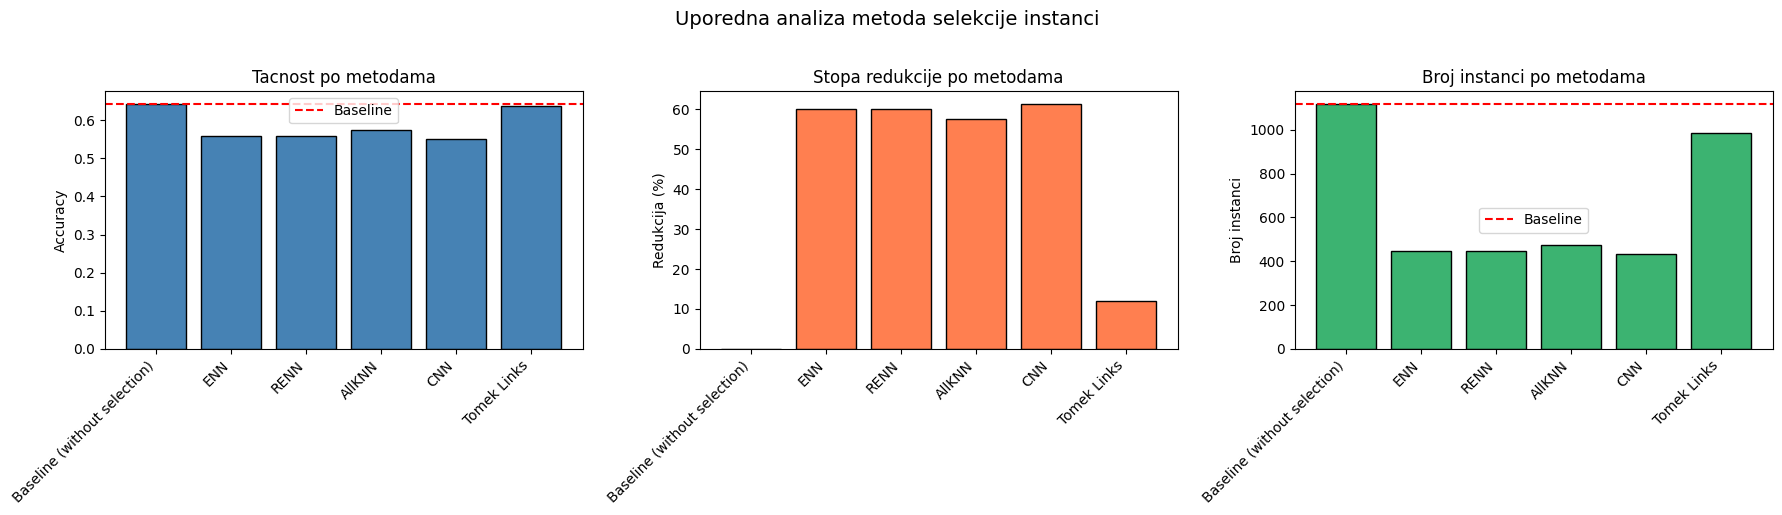

In [162]:
results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].round(4)
results_df['Predict time (s)'] = results_df['Predict time (s)'].round(4)

print(results_df.to_string(index=False))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = results_df['Method']
x = range(len(methods))

# Tacnost
axes[0].bar(x, results_df['Accuracy'], color='steelblue', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=45, ha='right')
axes[0].set_title('Tacnost po metodama')
axes[0].set_ylabel('Accuracy')
axes[0].axhline(y=results_df['Accuracy'].iloc[0], color='red', linestyle='--', label='Baseline')
axes[0].legend()

# Redukcija
axes[1].bar(x, results_df['Reduction (%)'], color='coral', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=45, ha='right')
axes[1].set_title('Stopa redukcije po metodama')
axes[1].set_ylabel('Redukcija (%)')

# Broj instanci
axes[2].bar(x, results_df['Num of instances'], color='mediumseagreen', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, rotation=45, ha='right')
axes[2].set_title('Broj instanci po metodama')
axes[2].set_ylabel('Broj instanci')
axes[2].axhline(y=results_df['Num of instances'].iloc[0], color='red', linestyle='--', label='Baseline')
axes[2].legend()

plt.suptitle('Uporedna analiza metoda selekcije instanci', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Confusion matrice za sve metode
Poredjenje confusion matrica omogucava da se vizuelno identifikuje kako svaka metoda selekcije instanci utice na klasifikaciju pojedinih klasa u odnosu na baseline.

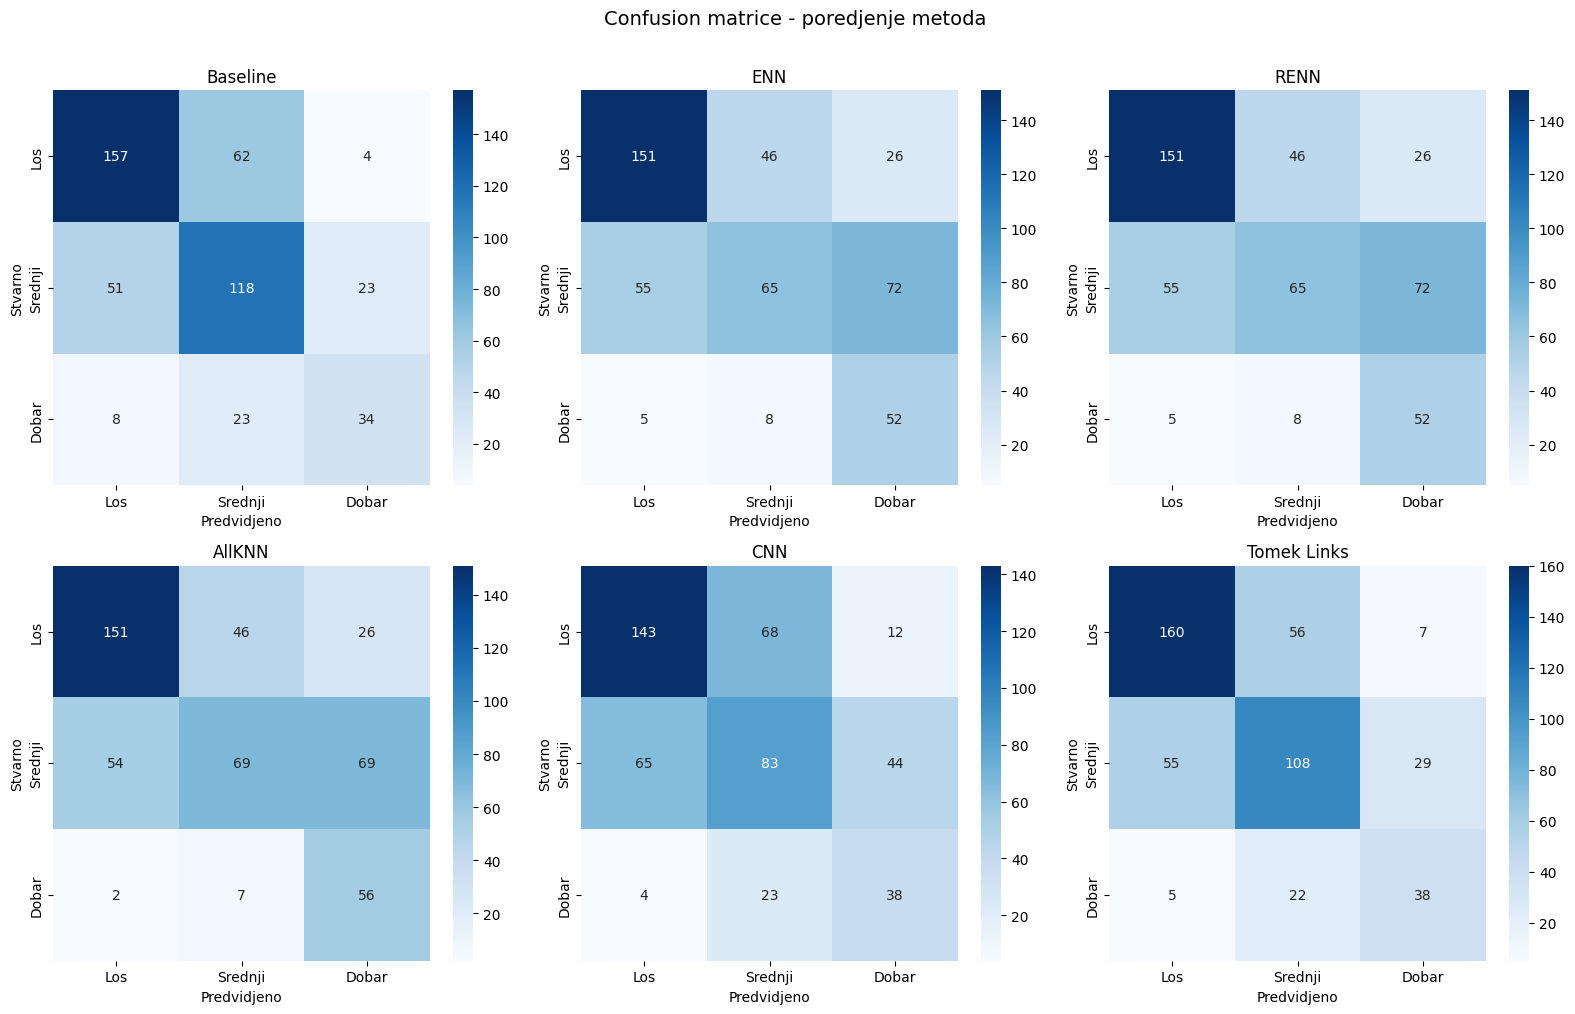

In [163]:
predictions = {
    'Baseline': y_pred,
    'ENN': y_pred_enn,
    'RENN': y_pred_renn,
    'AllKNN': y_pred_allknn,
    'CNN': y_pred_cnn,
    'Tomek Links': y_pred_tomek
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
labels = ['Los', 'Srednji', 'Dobar']

for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(f'{name}', fontsize=12)
    axes[i].set_xlabel('Predvidjeno')
    axes[i].set_ylabel('Stvarno')

plt.suptitle('Confusion matrice - poredjenje metoda', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Distribucija klasa pre i posle selekcije
Prikaz kako svaka metoda menja broj instanci po klasama. Ovo je vazno jer neke metode mogu neravnomerno uklanjati instance iz razlicitih klasa, sto dodatno menja balans i utice na klasifikaciju.

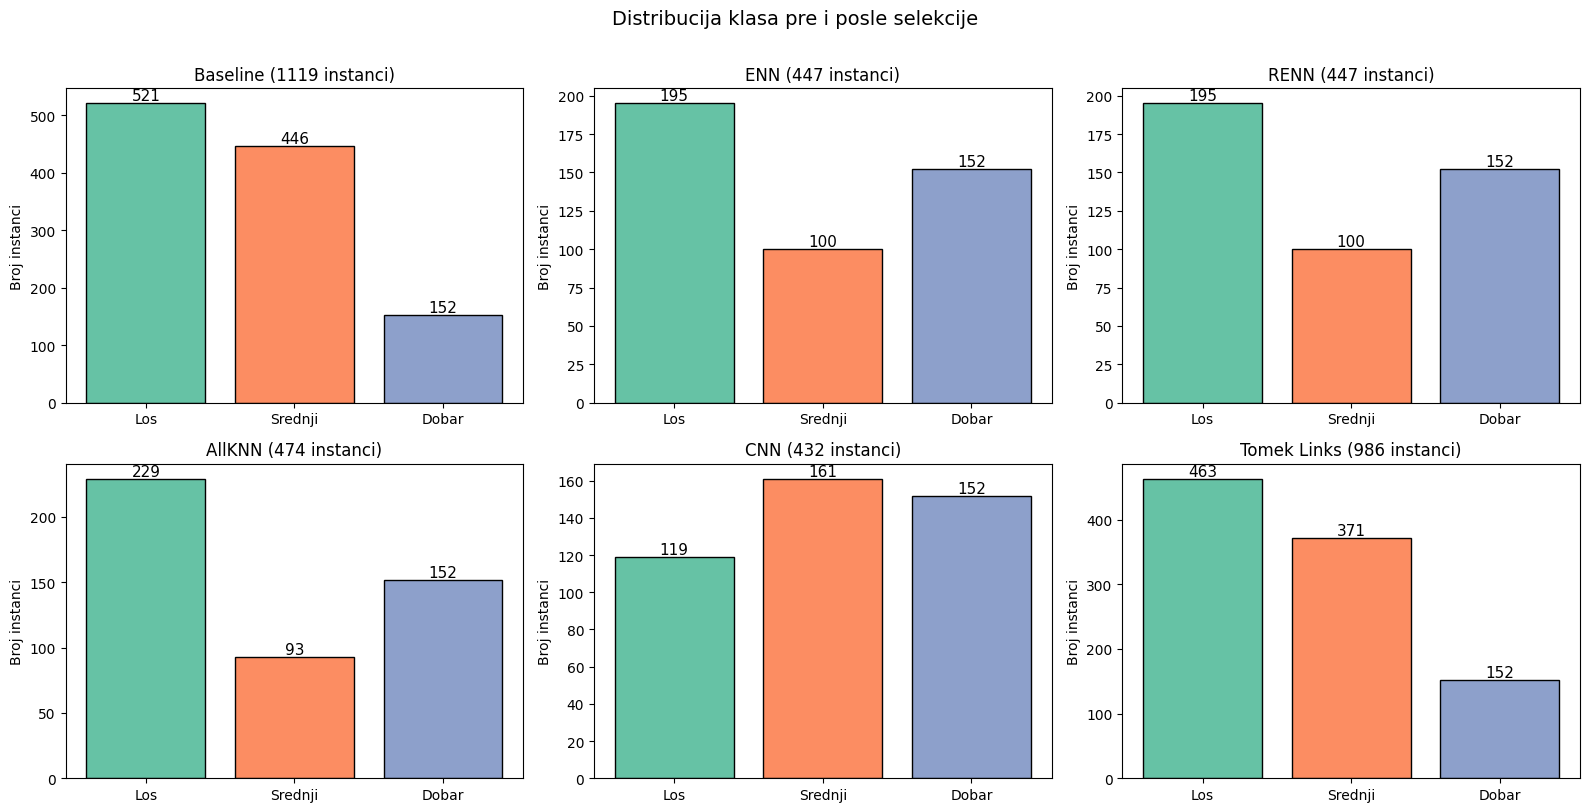

In [164]:
datasets = {
    'Baseline': y_train,
    'ENN': y_enn,
    'RENN': y_renn,
    'AllKNN': y_allknn,
    'CNN': y_cnn,
    'Tomek Links': y_tomek
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['Los', 'Srednji', 'Dobar']
colors = sns.color_palette('Set2', 3)

for i, (name, y_data) in enumerate(datasets.items()):
    counts = pd.Series(y_data).value_counts().sort_index()
    axes[i].bar(labels, counts, color=colors, edgecolor='black')
    axes[i].set_title(f'{name} ({len(y_data)} instanci)', fontsize=12)
    axes[i].set_ylabel('Broj instanci')
    for j, v in enumerate(counts):
        axes[i].annotate(f'{v}', (j, v), ha='center', va='bottom', fontsize=11)

plt.suptitle('Distribucija klasa pre i posle selekcije', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Zakljucak

Rezultati pokazuju da na ovom datasetu nijedna metoda selekcije instanci nije uspela da poboljsa tacnost u odnosu na baseline k-NN (0.6438). Ovo je posledica velikog preklapanja izmedju klasa Los i Srednji u feature space-u. Granice izmedju klasa nisu jasno definisane, sto znaci da se uklanjanjem instanci gube informacije potrebne za klasifikaciju.

Medjutim, rezultati jasno demonstriraju razlike izmedju kategorija metoda koje su obradjene u teorijskom delu:

- **Edition metode** (ENN, RENN, AllKNN) su bile preagresivne na ovom datasetu. Uklonile su 57-60% instanci i srusile tacnost za 7-9 procentnih poena, posebno pogadjajuci klasu Srednji. RENN je konvergirao u jednoj iteraciji sto znaci da ENN vec u prvom prolazu detektuje sve sumne instance.

- **Kondenzacija** (CNN) je postigla najvecu redukciju (61.4%) ali i najnizu tacnost (0.55), jer zadrzava granicne instance bez razlikovanja validnih od sumnih.

- **Tomek Links** se pokazao kao najstabilnija metoda. Uz najmanju redukciju (11.9%) sacuvao je tacnost prakticno identicnu baseline-u (0.6375), sto potvrdjuje da konzervativniji pristup bolje cuva kvalitet klasifikacije kada su klase jako isprepletane.

- **DROP3** kao hibridna metoda (ENN + kondenzacija) bi teoretski dao najbolji balans redukcije i tacnosti jer prvo cisti sum pa onda kondenzuje na cistim podacima. Medjutim, DROP3 nije dostupan u standardnim Python bibliotekama (scikit-learn, imbalanced-learn) pa nije demonstriran u prakticnom delu. Na osnovu rezultata ENN-a i CNN-a moze se ocekivati da bi DROP3 postigao redukciju od 80-90% uz bolje ocuvanje tacnosti od CNN-a zahvaljujuci inicijalnom ciscenju suma.

Kljucni zakljucak je da izbor metode selekcije instanci zavisi od karakteristika podataka. Na datasetima sa jasno razdvojenim klasama, agresivnije metode poput CNN ili ENN mogu postici veliku redukciju uz ocuvanu tacnost. Na datasetima sa velikim preklapanjem, poput ovog, konzervativni pristupi su bezbedniji izbor.